In [ ]:
%pip install numpy scipy matplotlib scikit-learn pandas

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.9 MB 1.9 MB/s eta 0:00:07
   -- ------------------------------------- 0.8/12.9 MB 1.9 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.9 MB 1.2 MB/s eta 0:00:10
   ---- ----------------------------------- 1.3/12.9 MB 1.2 MB/s eta 0:00:10
   ----- ---------------------------------- 1.8/12.9 MB 1.4 MB/s eta 0:00:08
   ------- -------------------------------- 2.4/12.9 MB 1.6 MB/s eta 0:00:07
   -------- ------------------------------- 2.6/12.9 MB 1.6 MB/s eta

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the file and its contents
file_path = "C:/Users/tarin/emg-controlled-arm-sim/EMG/Raw_csv/1_1.csv"
df = pd.read_csv(file_path)

# get the file and list headers and columns
print(df.shape)
print(df.columns.tolist())
df.head()

(63196, 10)
['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'channel7', 'channel8', 'class']


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0


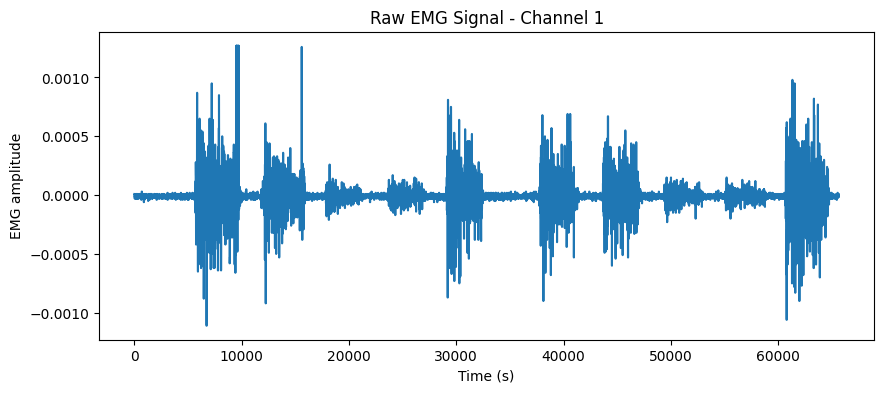

In [4]:
plt.figure(figsize=(10, 4))
channels=['channel1']

#plot data and labels
plt.plot(df['time'], df['channel1'])
plt.xlabel("Time (s)")
plt.ylabel("EMG amplitude")
plt.title("Raw EMG Signal - Channel 1")
plt.show()

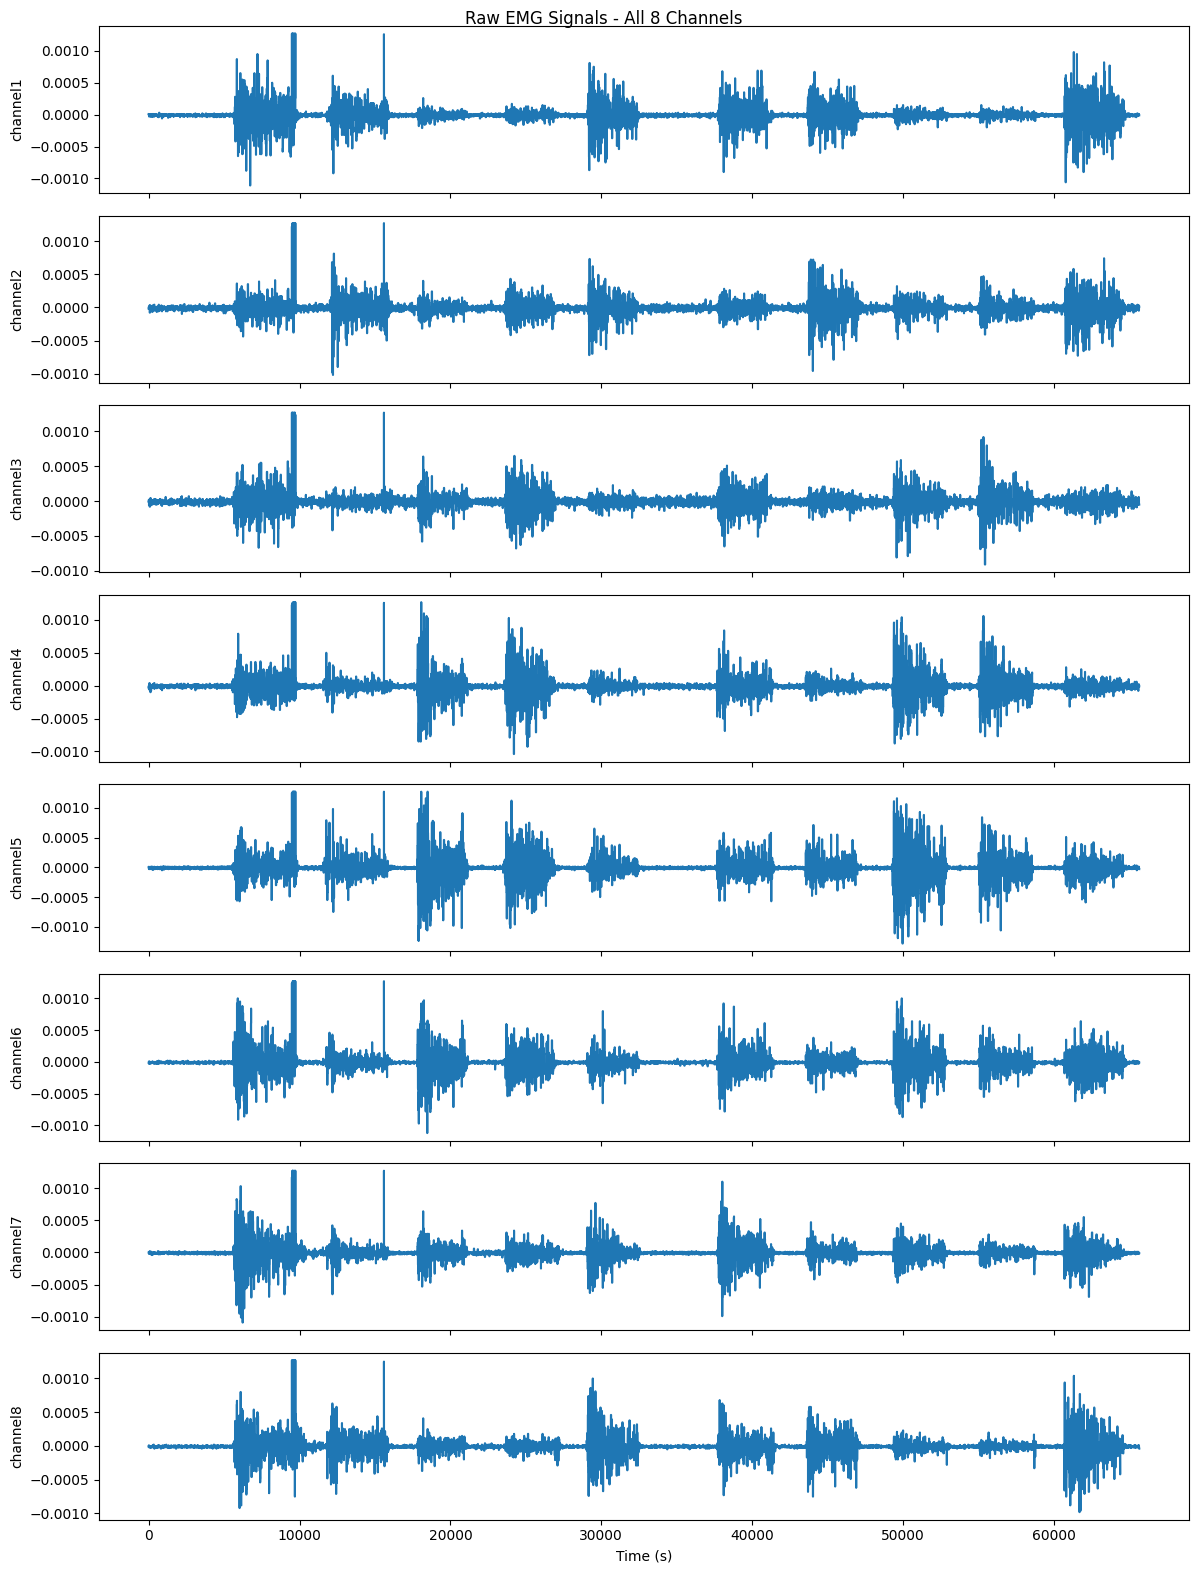

In [5]:
#groups all 8 channels into one big dataset
channels = ['channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'channel7', 'channel8']

#create subplots for the data
fig, axes = plt.subplots(8, 1, figsize=(12, 16), sharex=True)

#goes through the dataset and each column
for i, ch in enumerate(channels):
    axes[i].plot(df['time'], df[ch])
    axes[i].set_ylabel(ch)

#layout of the graph/chart
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Raw EMG Signals - All 8 Channels")
plt.tight_layout()
plt.show()


In [6]:
#differentiates into various gestures and counts how many across all 8 sets
print(df['class'].value_counts())

class
0    41272
3     3816
1     3780
6     3747
5     3615
2     3525
4     3441
Name: count, dtype: int64


In [ ]:
import numpy as np

#Find all differences between the time values
time_diffs = np.diff(df['time'].values)

# Only keep positive, "normal" diffs (ignore resets/jumps between trials)
normal_diffs = time_diffs[(time_diffs > 0) & (time_diffs < 100)]

#Determine mediane time step from the normal_diffs
median_dt = np.median(normal_diffs)
print(f"Median time step: {median_dt} ms")

#Conversion from ms to Hz
estimated_fs = 1000 / median_dt  
print(f"Estimated sampling rate: {estimated_fs:.2f} Hz")

Median time step: 1.0 ms
Estimated sampling rate: 1000.00 Hz


In [ ]:
#Import filtering functions
from scipy.signal import butter, filtfilt

#Create filter function, raw signal, low f, high f, sampling f, sharpness
#low and high f determined by meaningul EMG frequencies
def bandpass_filter(signal, lowcut=20, highcut=450, fs=1000, order=4):
    #Half the sampling rte, max signal the sample can represent
    nyquist = 0.5 * fs

    #normalize so the range is between 0-1 (for butter to work)
    low = lowcut / nyquist
    high = highcut / nyquist

    #Apply butterworth filter using normalized range
    b, a = butter(order, [low, high], btype='band')

    #filter forward and back, preserve signal timing
    filtered = filtfilt(b, a, signal)
    return filtered

#Set smapling frequency, number of samples EMG sensor collects per second
fs = 1000

#Apply filter function to channel 1
filtered_ch1 = bandpass_filter(df['channel1'].values, fs=fs)

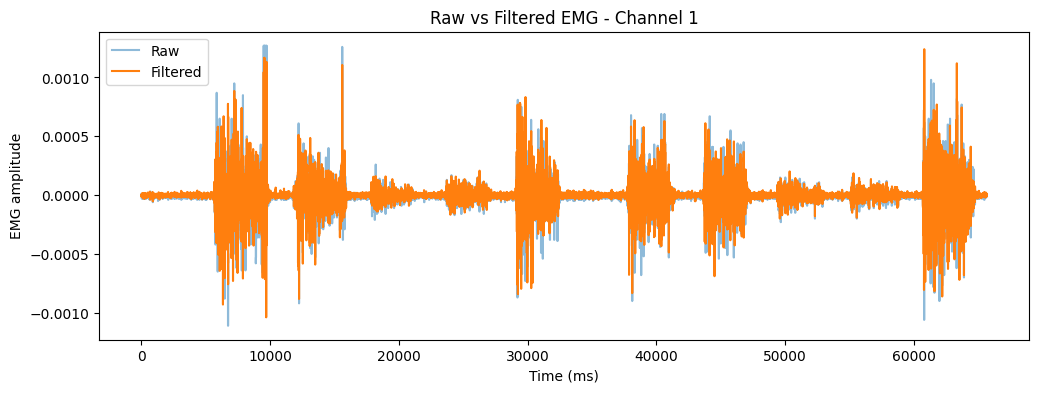

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(df['time'], df['channel1'], label='Raw', alpha=0.5)
plt.plot(df['time'], filtered_ch1, label='Filtered', linewidth=1.5)
plt.xlabel("Time (ms)")
plt.ylabel("EMG amplitude")
plt.title("Raw vs Filtered EMG - Channel 1")
plt.legend()
plt.show()

In [37]:
#Function for determing mean absolute value at each window
#Calculates average magnitude of EMG signal
#High = strong muscle contraction, Low = relaxed muscle
def mean_absolute_value(window):
    return np.mean(np.abs(window))

#Function for root mean square
#Measures the intensity of EMG signal, larger spikes = more weight
#Force of contraction
def root_mean_square(window):
    return np.sqrt(np.mean(window**2))

#Measures waveform length
#Change of the signal from one to the next, signal complexity
def waveform_length(window):
    return np.sum(np.abs(np.diff(window)))

#Define zero crossing rate, help differentiate class 1 from class 0, looks at oscillations
def zero_crossing_rate(window, threshold=0.00001):
    # Count sign changes, ignoring tiny noise fluctuations near zero
    signs = np.sign(window)
    signs[np.abs(window) < threshold] = 0  # treat near-zero as no crossing
    crossings = np.sum(np.abs(np.diff(signs)) > 0)
    return crossings

In [38]:
#Analyse every 200ms of data as one group (of 200 samples)
window_size = 200   # ms
#Start new window 100ms after the prior one, smoother predictions
step_size = 50      # ms (50% overlap between windows)

channels = ['channel1', 'channel2', 'channel3', 'channel4',
            'channel5', 'channel6', 'channel7', 'channel8']

#Store data
features_list = []
#Store potential gestures
labels_list = []

#loop through df
for start in range(0, len(df) - window_size, step_size):
    end = start + window_size
    window_df = df.iloc[start:end]
    
    #MAV, RMS, and WL for each window stores in this empty list
    row_features = []
    for ch in channels:
        signal_window = window_df[ch].values #Takes the values of the channel in the current window
        #For the specific channel in the current window, record these values
        row_features.append(mean_absolute_value(signal_window))
        row_features.append(root_mean_square(signal_window))
        row_features.append(waveform_length(signal_window))
        row_features.append(zero_crossing_rate(signal_window))
    
    #Each window has 24 values (8 channels x 3 features)
    features_list.append(row_features)
    
    #Label the window based on most common class
    window_label = window_df['class'].mode()[0]
    labels_list.append(window_label)

features_array = np.array(features_list)
labels_array = np.array(labels_list)

print("Features shape:", features_array.shape) #Prints 630 windows with 24 features per window
print("Labels shape:", labels_array.shape) # one label for each window (so 630 labels)

Features shape: (1260, 32)
Labels shape: (1260,)


In [39]:
# Create table of all values (channels and respective features)
feature_names = [f"{ch}_{feat}" for ch in channels for feat in ['MAV', 'RMS', 'WL', 'ZCR']]
features_df = pd.DataFrame(features_array, columns=feature_names)
features_df['label'] = labels_array
features_df.head() #windows x channel_feature

,channel1_MAV,channel1_RMS,channel1_WL,channel1_ZCR,channel2_MAV,channel2_RMS,channel2_WL,channel2_ZCR,channel3_MAV,channel3_RMS,...,channel6_ZCR,channel7_MAV,channel7_RMS,channel7_WL,channel7_ZCR,channel8_MAV,channel8_RMS,channel8_WL,channel8_ZCR,label
0,0.000012,0.000015,0.00034,12.0,0.000021,0.000033,0.00079,15.0,0.000030,0.000038,...,8.0,0.000014,0.000017,0.00029,13.0,0.000010,0.000013,0.00026,14.0,0
1,0.000011,0.000014,0.00038,13.0,0.000022,0.000033,0.00077,13.0,0.000027,0.000036,...,8.0,0.000014,0.000017,0.00025,9.0,0.000011,0.000013,0.00019,10.0,0
2,0.000011,0.000015,0.00042,15.0,0.000016,0.000022,0.00068,12.0,0.000021,0.000025,...,6.0,0.000011,0.000016,0.00031,11.0,0.000010,0.000013,0.00023,10.0,0
3,0.000009,0.000013,0.00037,16.0,0.000017,0.000023,0.00061,13.0,0.000019,0.000022,...,9.0,0.000011,0.000016,0.00029,10.0,0.000008,0.000011,0.00027,12.0,0
4,0.000011,0.000014,0.00034,13.0,0.000016,0.000023,0.00060,12.0,0.000023,0.000026,...,8.0,0.000008,0.000012,0.00023,9.0,0.000010,0.000013,0.00026,9.0,0


In [41]:
#Determines how many windows belong in each gesture/class
print(features_df['label'].value_counts())


label
0    819
3     77
1     76
6     75
5     73
2     71
4     69
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = features_df.drop('label', axis=1) #Only include columns that focus on features
y = features_df['label'] #learn to predict the label/class/gesture

#80/20 split of train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) #will test the same data everytime, stratify is used to have the same number of windows everytime

#Number of train and test samples
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1008
Testing samples: 252


In [ ]:
from sklearn.ensemble import RandomForestClassifier

#Multiple decision trees
clf = RandomForestClassifier(
    n_estimators=100, #100 trees, highest number wins
    class_weight='balanced',  #class imbalance
    random_state=42 #same model everytime code is ran
)

clf.fit(X_train, y_train) #actual training begins

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test) #give model the test data

print(classification_report(y_test, y_pred)) # see what the model predicts

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       164
           1       1.00      0.13      0.24        15
           2       0.68      0.93      0.79        14
           3       0.68      1.00      0.81        15
           4       0.91      0.71      0.80        14
           5       0.93      0.93      0.93        15
           6       0.75      0.80      0.77        15

    accuracy                           0.84       252
   macro avg       0.83      0.77      0.75       252
weighted avg       0.85      0.84      0.82       252



In [ ]:
from sklearn.metrics import confusion_matrix

#Confusion matrix: compares actual and predicted labels
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm) #Diagonals are correct guesses

# Specifically what class 1 gets misclassified as
class_1_index = list(clf.classes_).index(1)
print("\nClass 1 predictions breakdown:")
#Loop through the matrix to identfify specifics of each misclassification
for i, cls in enumerate(clf.classes_):
    print(f"  Predicted as {cls}: {cm[class_1_index][i]} times")

Confusion matrix:
[[145   0   6   7   1   1   4]
 [ 13   2   0   0   0   0   0]
 [  1   0  13   0   0   0   0]
 [  0   0   0  15   0   0   0]
 [  4   0   0   0  10   0   0]
 [  1   0   0   0   0  14   0]
 [  3   0   0   0   0   0  12]]

Class 1 predictions breakdown:
  Predicted as 0: 13 times
  Predicted as 1: 2 times
  Predicted as 2: 0 times
  Predicted as 3: 0 times
  Predicted as 4: 0 times
  Predicted as 5: 0 times
  Predicted as 6: 0 times


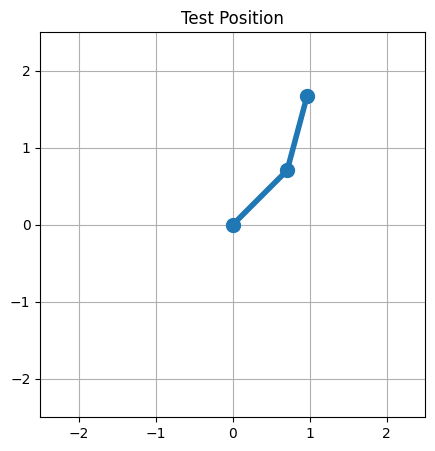

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Define arm lengths of each segment
L1, L2 = 1.0, 1.0  

#Define function to identify locations fo elbow and the hand
def forward_kinematics(theta1, theta2):
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (0, 0), (x1, y1), (x2, y2)

#Define function to plot the arm on a graph
def draw_arm(theta1, theta2, title="Arm Position"):
    shoulder, elbow, hand = forward_kinematics(theta1, theta2)
    
    xs = [shoulder[0], elbow[0], hand[0]]
    ys = [shoulder[1], elbow[1], hand[1]]
    
    plt.figure(figsize=(5, 5))
    plt.plot(xs, ys, 'o-', linewidth=4, markersize=10)
    plt.xlim(-2.5, 2.5)
    plt.ylim(-2.5, 2.5)
    plt.grid(True)
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()

#Create a test position and plot it
draw_arm(np.radians(45), np.radians(30), "Test Position")

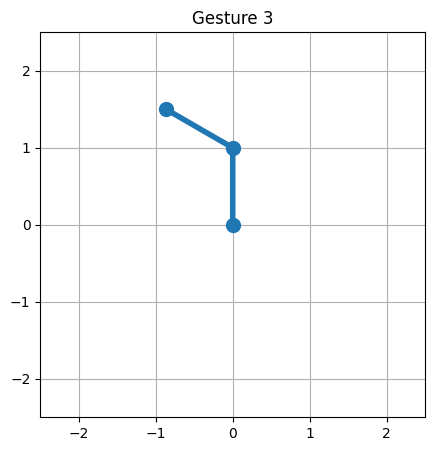

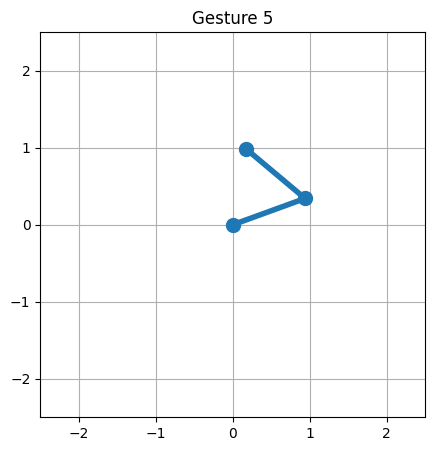

In [57]:
#Assign a gesture to a unique arm movement; easier to show on graph
gesture_to_angles = {
    0: (np.radians(0), np.radians(0)),   
    1: (np.radians(30), np.radians(20)),
    2: (np.radians(60), np.radians(40)),
    3: (np.radians(90), np.radians(60)),
    4: (np.radians(45), np.radians(90)),
    5: (np.radians(20), np.radians(120)),
    6: (np.radians(75), np.radians(-30)),
}

#Associate each angle to the gesture class
def draw_arm_for_gesture(gesture_class):
    theta1, theta2 = gesture_to_angles[gesture_class]
    draw_arm(theta1, theta2, title=f"Gesture {gesture_class}")

# Test a few
draw_arm_for_gesture(3)
draw_arm_for_gesture(5)

Sample Index: 116
True Gesture: 0
Predicted Gesture: 0


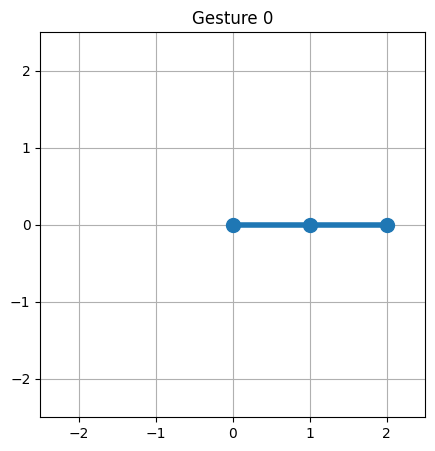

✅ Correct Prediction
Sample Index: 0
True Gesture: 2
Predicted Gesture: 2


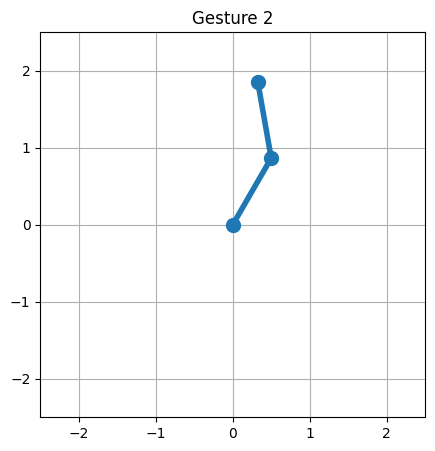

✅ Correct Prediction
Sample Index: 166
True Gesture: 6
Predicted Gesture: 6


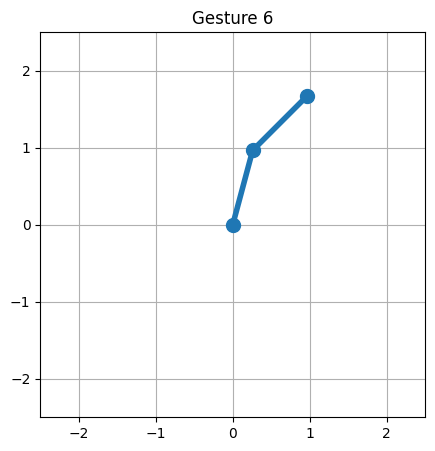

✅ Correct Prediction
Sample Index: 224
True Gesture: 0
Predicted Gesture: 0


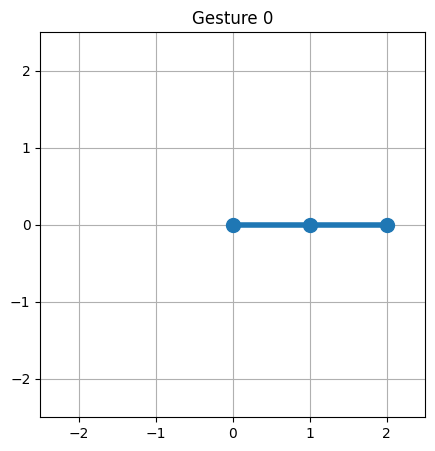

✅ Correct Prediction
Sample Index: 175
True Gesture: 6
Predicted Gesture: 6


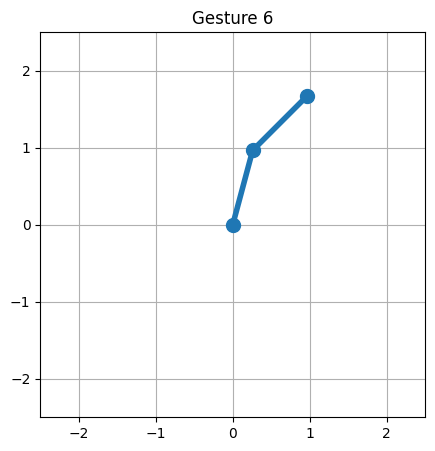

✅ Correct Prediction
Sample Index: 161
True Gesture: 3
Predicted Gesture: 3


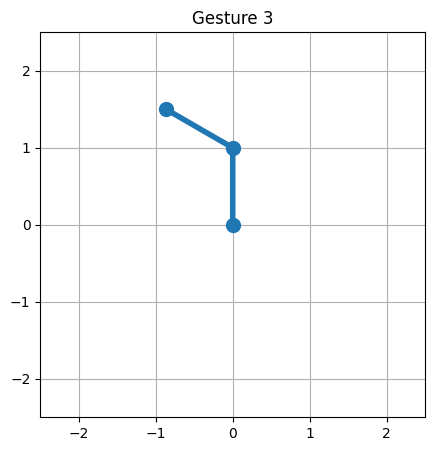

✅ Correct Prediction
Sample Index: 250
True Gesture: 1
Predicted Gesture: 0


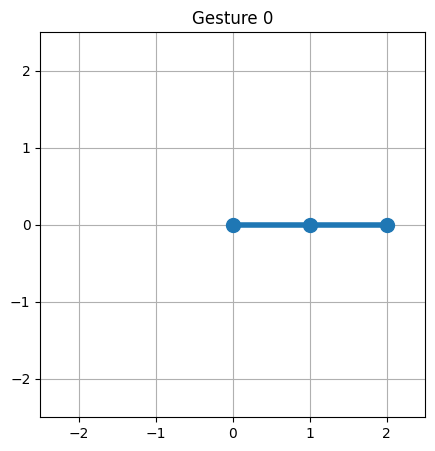

❌ Misclassified
Sample Index: 194
True Gesture: 0
Predicted Gesture: 0


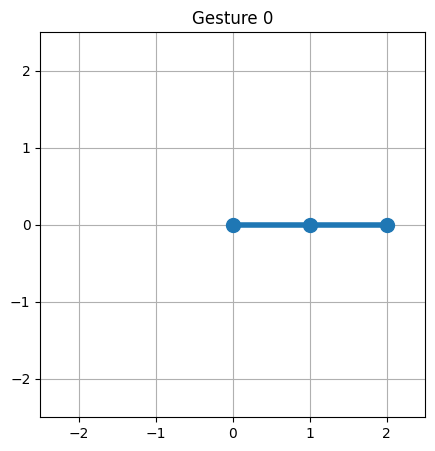

✅ Correct Prediction
Sample Index: 154
True Gesture: 0
Predicted Gesture: 0


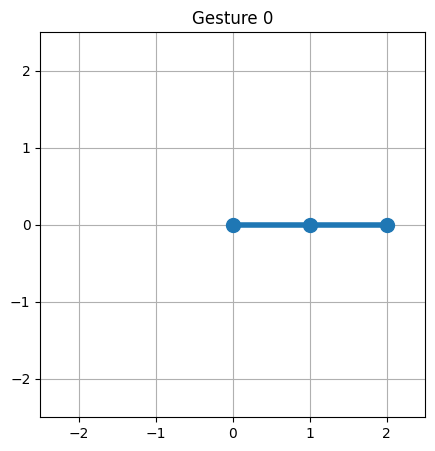

✅ Correct Prediction
Sample Index: 181
True Gesture: 3
Predicted Gesture: 3


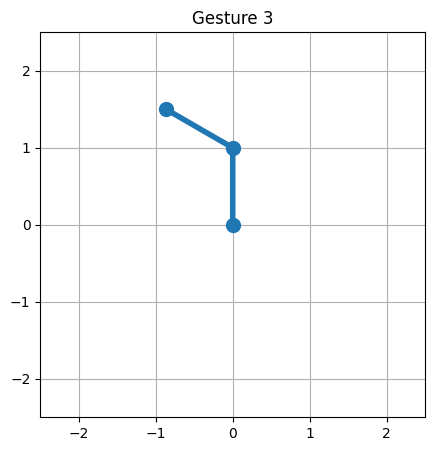

✅ Correct Prediction


In [66]:
#Choose about 5 samples (instead of the entire data set)
sample_indices = np.random.choice(len(X_test), size=10, replace=False)


for idx in sample_indices:
    true_label = y_test.iloc[idx] #Pulls the actual gesture from data set
    predicted_label = clf.predict(X_test.iloc[[idx]])[0] #Predict gesture from 
    
    print("=" * 40)
    print(f"Sample Index: {idx}")
    print(f"True Gesture: {true_label}")
    print(f"Predicted Gesture: {predicted_label}")

    #Draw arm for both predicted and true gesture
    #print(f"True gesture: {true_label}, Predicted: {predicted_label}")
    draw_arm_for_gesture(predicted_label)

    if true_label == predicted_label:
        print("✅ Correct Prediction")
    else:
        print("❌ Misclassified")

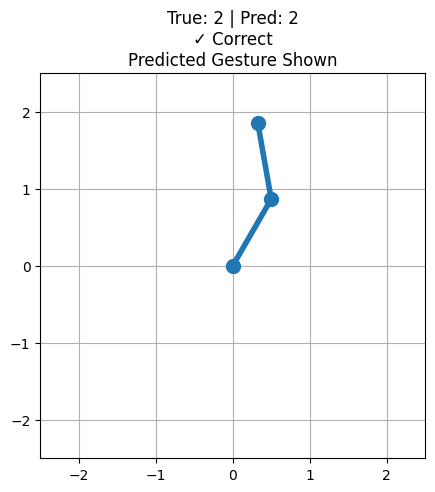

In [70]:
import matplotlib.animation as animation
from IPython.display import HTML

def animate_predictions(indices):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    def update(frame):
        ax.clear()
        idx = indices[frame]
        true_label = y_test.iloc[idx]
        predicted = clf.predict(X_test.iloc[[idx]])[0]
        theta1, theta2 = gesture_to_angles[predicted]
        shoulder, elbow, hand = forward_kinematics(theta1, theta2)
        
        xs = [shoulder[0], elbow[0], hand[0]]
        ys = [shoulder[1], elbow[1], hand[1]]
        
        ax.plot(xs, ys, 'o-', linewidth=4, markersize=10)
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.grid(True)
        ax.set_aspect('equal')
        if predicted == true_label:
            status = "✓ Correct"
        else:
            status = "✗ Incorrect"

        ax.set_title(
            f"True: {true_label} | Pred: {predicted}\n{status}\nPredicted Gesture Shown"
        )
    
    anim = animation.FuncAnimation(fig, update, frames=len(indices), interval=800, repeat=True)
    return anim

sample_indices = [0, 5, 10, 15, 20, 25, 30]
anim = animate_predictions(sample_indices)
HTML(anim.to_jshtml())

In [ ]:
anim.save('C:/Users/tarin/emg-controlled-arm-sim/results/demo.gif', writer='pillow', fps=1)